[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03a_baseline.ipynb)

# 03a — Baseline Experiment: Random Search and a Rule-Based Sweep

## 1. Overview

This notebook evaluates two **baseline optimization methods** for multi-band antenna tilt coordination: choosing one
tilt per `(cell, band)` pair to improve coverage while limiting co-band overlap. The baselines are
the reference TuRBO (notebook 03b) is read against.

**Goals.**

- Run two simple, reproducible baselines on the same simulator, scenario and objective as TuRBO.
- Measure what they change on every KPI, and where on the map.
- Set the reference performance level for the method comparison in notebook 04.

The problem formulation (the tilt vector and its bounds) and the KPI definitions are described in notebook 01
(sections 2, 7, 8 and 12) and are not repeated here.

**Outputs.** One run directory per method and seed under `outputs/optim/`, tables under
`reports/tables/03a_baseline/`, figures under `reports/figures/03a_baseline/`. **Requirements.** A CUDA GPU.
The shell equivalent of the runs is `task baseline` (random search) and `task baseline -- optim/method=rule`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import CapacitySpec, max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.objective import MAXIMISED
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03a_baseline"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03a_baseline"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("random", "rule")

## 2. Baseline Methods

### Random search (`optim/method=random`)

Scrambled Sobol points drawn uniformly over the tilt box, each ray-traced and scored; the configuration with the
highest objective is kept. It is matched to TuRBO on the evaluation budget and seed, and its first `n_init` points
are TuRBO's initial design, so any gap between the two is what the model contributes.

### Rule-based sweep (`optim/method=rule`)

The operator heuristic: every cell on a band shares one tilt, and the band tilts are tuned by coordinate descent,
trying `n_steps` values per band per pass over `n_rounds` passes. It is deterministic and not budget-matched.

### Why these baselines?

- Neither needs a learned model.
- Both are straightforward to reproduce from a seed and a config.
- Random search makes no assumption about the objective landscape; the sweep encodes the one an operator would make.
- Together they bound what TuRBO has to beat: an unstructured search at equal budget and a structured one at far
  lower cost.

## 3. Experimental Setup

Every value below is read from the composed config and the simulation output, not restated by hand.

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)
radio_cfg = cfg.simulation.radio_map
n_rows, n_cols = maps.grid_shape(baseline)

network = pd.DataFrame(
    {
        "Parameter": [
            "Sites (nodes)",
            "Cells",
            "Frequency bands",
            "Optimized variables",
            "Tilt range [°]",
            "Current tilt [°]",
            "Tilt step, maximum tilt change",
        ],
        "Value": [
            cells["node"].nunique(),
            len(space.cells),
            ", ".join(label(band) for band in space.band_names),
            f"{space.n_dim} ({len(space.cells)} cells x {len(space.band_names)} bands)",
            f"{space.lower.min():g} – {space.upper.max():g}",
            ", ".join(f"{value:g}" for value in np.unique(space.baseline)),
            "Not constrained: continuous tilt inside the box",
        ],
    }
)
mechanisms = [
    name
    for name in ("los", "specular_reflection", "diffuse_reflection", "refraction", "diffraction")
    if bool(radio_cfg[name])
]
simulation = pd.DataFrame(
    {
        "Parameter": [
            "Simulator",
            "Scene",
            "Scenario",
            "Grid resolution [m]",
            "Evaluation tiles",
            "Rays per transmitter",
            "Maximum path depth",
            "Propagation mechanisms",
        ],
        "Value": [
            "Sionna RT",
            str(cfg.simulation.scene.name),
            str(baseline["scenario_id"]),
            f"{float(baseline['tile_size_m']):g}",
            f"{n_rows * n_cols} ({n_rows} x {n_cols})",
            f"{int(radio_cfg.samples_per_tx):,}",
            int(radio_cfg.max_depth),
            ", ".join(mechanisms),
        ],
    }
)
users = pd.DataFrame(
    {
        "Parameter": ["UE reports", "Intervals", "Distribution"],
        "Value": [
            len(ue),
            ue["t_index"].nunique(),
            "Uniform open-ground background plus Gaussian hotspots (notebook 00)",
        ],
    }
)
for name, table in (("network", network), ("simulation", simulation), ("users", users)):
    save_table(table, f"setup_{name}")
    display(table)

,Parameter,Value
0,Sites (nodes),4
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Optimized variables,36 (12 cells x 3 bands)
4,Tilt range [°],0 – 15
5,Current tilt [°],"8, 10, 12"
6,"Tilt step, maximum tilt change",Not constrained: continuous tilt inside the box


,Parameter,Value
0,Simulator,Sionna RT
1,Scene,data/external/scene/scene.xml
2,Scenario,scn_7d938e15f9ac4618
3,Grid resolution [m],20
4,Evaluation tiles,101060 (326 x 310)
5,Rays per transmitter,"10,000,000"
6,Maximum path depth,8
7,Propagation mechanisms,"los, specular_reflection, refraction"


,Parameter,Value
0,UE reports,10087
1,Intervals,672
2,Distribution,Uniform open-ground background plus Gaussian h...


Every candidate is scored on all UEs, so the numbers from section 6 onwards are the search's own measurements.

## 4. Baseline Configuration

Both methods start from the committed network configuration, which is always evaluation 0 of a run.

In [4]:
def method_config(method):
    return load_config(overrides=[f"optim/method={method}", *CONFIG_OVERRIDES]).optim


random_cfg, rule_cfg = method_config("random"), method_config("rule")
n_band = len(space.band_names)
budgets = pd.DataFrame(
    {
        "Parameter": [
            "Search strategy",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Search seeds",
            "Initial configuration",
            "Solutions published",
        ],
        label("random"): [
            "Scrambled Sobol sampling over the tilt box",
            int(random_cfg.method.budget.n_init) + int(random_cfg.method.budget.n_iter),
            f"n_init={random_cfg.method.budget.n_init}, n_iter={random_cfg.method.budget.n_iter}",
            ", ".join(map(str, SEEDS)),
            "Current network",
            int(random_cfg.n_solutions),
        ],
        label("rule"): [
            "One tilt per band, coordinate descent",
            f"at most {n_band * int(rule_cfg.method.n_steps) * int(rule_cfg.method.n_rounds)}",
            f"n_steps={rule_cfg.method.n_steps}, n_rounds={rule_cfg.method.n_rounds}",
            "Deterministic",
            "Current network",
            int(rule_cfg.n_solutions),
        ],
    }
)
save_table(budgets, "baseline_configuration")
budgets

,Parameter,Random search,Rule-based sweep
0,Search strategy,Scrambled Sobol sampling over the tilt box,"One tilt per band, coordinate descent"
1,Evaluations (excluding the incumbent),144,at most 120
2,Budget split,"n_init=16, n_iter=128","n_steps=10, n_rounds=4"
3,Search seeds,42,Deterministic
4,Initial configuration,Current network,Current network
5,Solutions published,4,4


## 5. Runs

Each run evaluates the current configuration first, then searches, then re-traces its winner once to archive its
radio map. A run already on disk for the same method and seed is reused; delete its directory under `outputs/optim/` to
repeat it. The runs are then checked comparable with the current radio map: same scenario, grid, solver settings,
bands and KPI definition.

In [5]:
def on_disk():
    # The newest finished run of each method and seed.
    return run_store.latest_per_method_and_seed(run_store.discover(cfg.optim.output.dir))


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("random", seed) not in done:
        run(load_config(overrides=["optim/method=random", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

# Deterministic, so one run; its seed only labels it.
if not any(method == "rule" for method, _ in done):
    run(load_config(overrides=["optim/method=rule", f"optim.seed={SEEDS[0]}", *CONFIG_OVERRIDES]))

runs = [r for r in on_disk() if r.method == "rule" or (r.method == "random" and r.seed in SEEDS)]
checks = run_store.verify(runs, baseline, cfg)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
# Each method's best run over its seeds, for the per-method sections below.
best = compare.best_run_per_method(runs)

2 runs; 24 of 24 comparability checks hold


## 6. Initial Network State

The committed configuration, scored on every UE. Mean overlapping neighbours (co-band cells within the overlap margin
of the serving cell, summed over bands, averaged over covered tiles) is a diagnostic computed from the radio map; no
score reads it.

In [6]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


incumbent = runs[0].incumbent_kpi
baseline_rsrp = baseline["rsrp_dbm"].astype(float)
initial = pd.DataFrame(
    {
        "kpi": [*incumbent.as_dict(), "Mean overlapping neighbours"],
        "direction": [compare.direction(name) for name in incumbent.as_dict()] + ["minimise"],
        "value": [
            *incumbent.as_dict().values(),
            mean_overlap_neighbors(baseline_rsrp),
        ],
    }
)
initial = readable(initial.rename(columns={"value": "Initial value"}))
save_table(initial, "initial_state")
initial

,KPI,Direction,Initial value
0,Coverage hole rate,minimise,0.1125
1,Co-band overlap rate,minimise,0.3164
2,Overlap neighbours per covered tile,minimise,0.9625
3,Weak coverage rate,minimise,0.3069
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644
5,"Median RSRP, p50 [dBm]",maximise,-84.1068
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729
7,"Median SINR, p50 [dB]",maximise,8.4932
8,Served UE rate,maximise,0.5265
9,Cell load imbalance (CoV),minimise,0.9098


## 7. Optimization Process and Objective

Every candidate goes through the same loop, and every KPI is a measurement: nothing is predicted by a surrogate.

```text
Current tilt configuration (evaluation 0)
        │
        ▼
Generate candidate tilt ── random: Sobol point · rule: one band's shared tilt
        │
        ▼
Apply constraints ──────── clip to [tilt_min, tilt_max] per cell-band
        │
        ▼
Radio simulation ───────── Sionna RT, one solve per band
        │
        ▼
Compute KPIs and J ─────── src/optim/objective.py
        │
        ▼
Keep best configuration ── highest J; a tie keeps the earlier evaluation
```

Both methods maximise the project objective ([ADR 0003](../docs/adr/0003-contraharmonic-objective-and-kpi-set.md)):

$$
J = \frac{1}{|G|}\sum_{g \in G} \frac{\sum_b u_b(g)^2}{\sum_b u_b(g)},
\qquad
u_b(g) = \lambda_b(g)\, e^{1 - \lambda_b(g)}\, s_b(g),
\qquad
\lambda_b(g) = 1 + m_b(g)
$$

Every band is scored at every tile.
- $m_b(g)$ counts the other cells **on band $b$** above $T_\text{cov}$ and within $\Delta_R$ of that band's
  strongest. So $\lambda_b(g)$ is the number of cells contending to serve tile $g$ on band $b$, and $\lambda_b = 0$
  where the band does not cover the tile.
- $\lambda e^{1 - \lambda}$ is worth exactly **1 at $\lambda = 1$**, 0.736 at 2, 0.406 at 3 and 0 at 0: a band pays
  for one dominant server.
- $s_b(g)$ scales that by how far the band's strongest cell sits between $T_\text{cov}$ and $T_\text{weak}$,
  clipped to $[0, 1]$. A server at $-90$ dBm or better keeps all of it, and one just out of a hole keeps almost none.

The tile then takes the **contraharmonic mean** of its bands' scores, $\sum_b u_b^2 / \sum_b u_b$. Each band is
weighted by its own score, so the tile lies between the plain mean and its best band, and a crowded or marginal
second layer lowers it. A tile no band covers scores 0.

So **$J \in [0, 1]$** and **higher is better**. 1 would mean every covered band on every tile has exactly one
serving cell at or above $T_\text{weak}$. The objective has no free parameters and reads no band preference and
no demand. The KPIs are reported beside it, tile-uniform and band-collapsed, and none of them is weighted into it.

In [7]:
# The objective has no parameters of its own (ADR 0003): it reads three KPI
# thresholds and nothing else.
parameters = pd.DataFrame(
    {
        "Parameter": ["T_cov [dBm]", "T_weak [dBm]", "Delta_R [dB]", "J range"],
        "Value": [
            cfg.kpi.hole_dbm,
            cfg.kpi.weak_dbm,
            cfg.kpi.overlap_margin_db,
            "[0, 1], maximised",
        ],
    }
)
save_table(parameters, "objective_parameters")
parameters

,Parameter,Value
0,T_cov [dBm],-120.0
1,T_weak [dBm],-90.0
2,Delta_R [dB],6.0
3,J range,"[0, 1], maximised"


## 8. Optimization Progress

Best value found so far per evaluation, from the search history. Random search is shown as the mean over seeds with
the min–max band.

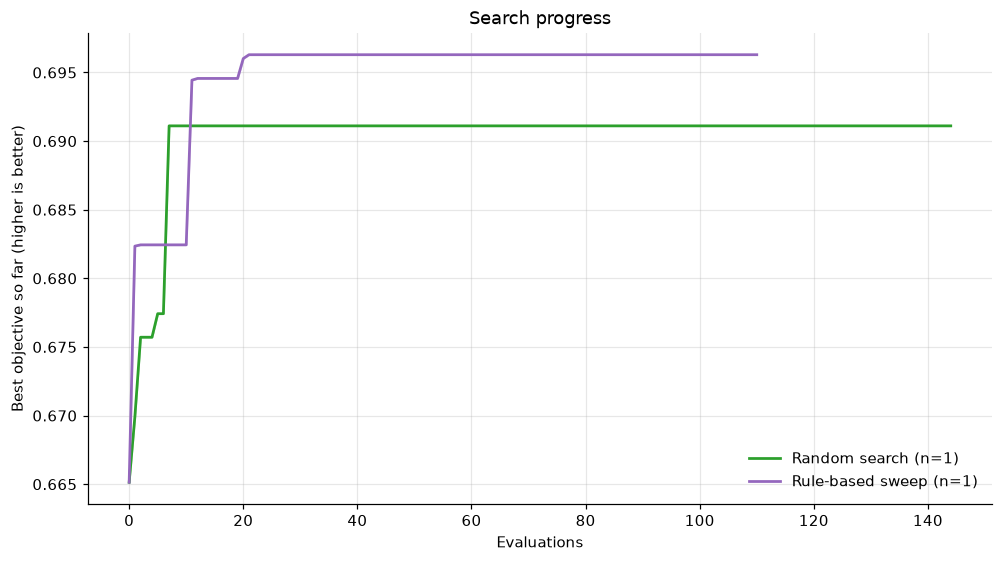

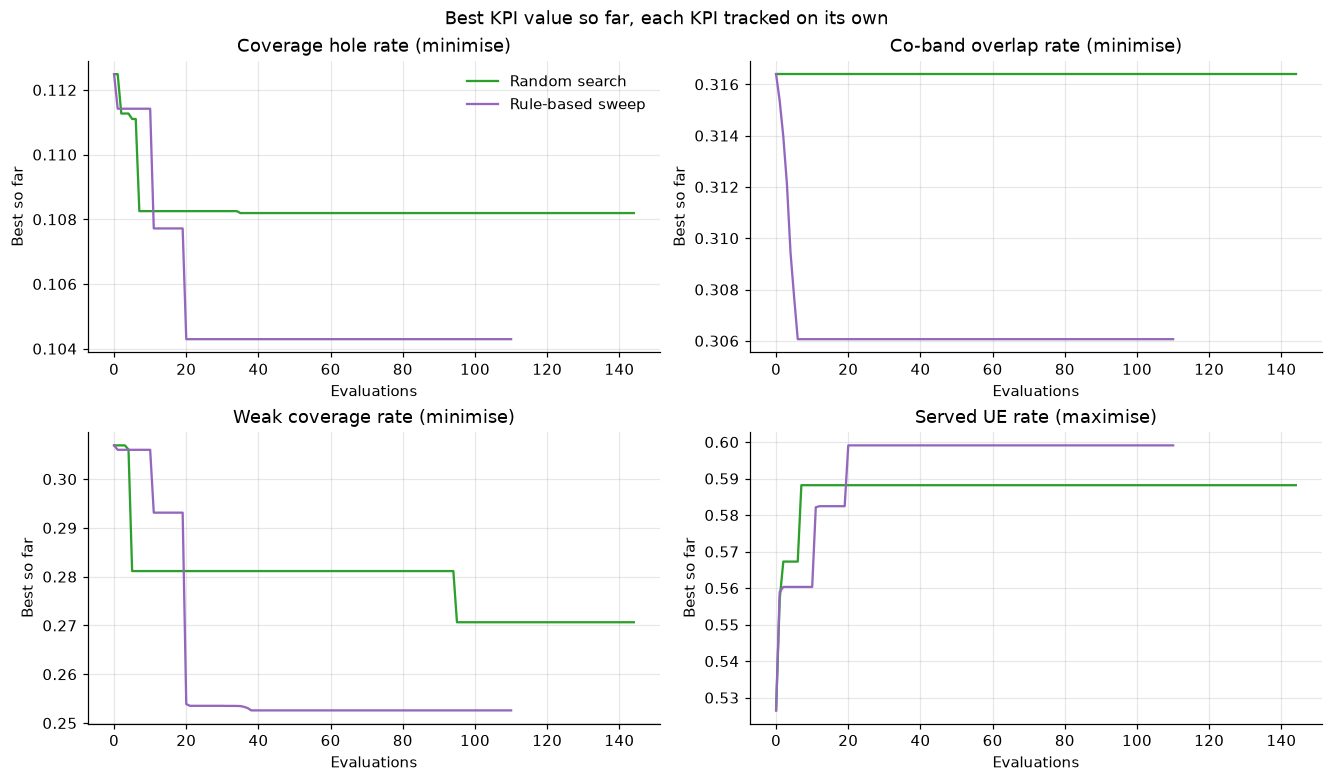

In [8]:
trace = compare.convergence(runs)
figure = plots.convergence_plot(trace)
save_fig(figure, "search_progress")
plt.show()

figure, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), constrained_layout=True)
for axis, name in zip(axes.ravel(), ("hole_rate", "overlap_rate", "weak_rate", "served_rate"), strict=True):
    part = trace[trace["kpi"] == name]
    for method, group in part.groupby("method", sort=False):
        mean = group.groupby("iteration")["value"].mean()
        axis.plot(mean.index, mean.to_numpy(), color=plots.COLOURS.get(method), label=label(method))
    axis.set_title(f"{label(name)} ({compare.direction(name)})")
    axis.set_xlabel("Evaluations")
    axis.set_ylabel("Best so far")
axes[0, 0].legend()
figure.suptitle("Best KPI value so far, each KPI tracked on its own")
save_fig(figure, "kpi_progress")
plt.show()

Each KPI panel tracks that KPI's own best value, which need not come from the configuration with the best J.

**Observations.** Random search found its best configuration at evaluation 7, and none of the later 138 draws beat
it. Its best J is 0.6911, against the current configuration's 0.6651 (+3.90 %). The rule-based sweep gets its whole
gain in its first pass over the three bands: 0.6963 by evaluation 21, after which the remaining 90 evaluations do not
improve on it. It ends **above** random search on J at about two-thirds of the ray-tracing cost (4.5 minutes against
6.6), and it leads TuRBO from evaluation 21 until TuRBO passes it at evaluation 32 (notebook 04).

$J$ scores each band for one dominant cell at usable strength and takes the contraharmonic mean over the tile's bands
(ADR 0003). It is bounded in $[0, 1]$, and these values compare with nothing scored under an earlier objective. From
0.6651, the most any configuration could gain is 0.3349, and the sweep takes 9.3 % of that.

**Read the gain beside its cost: overlap neighbours per covered tile worsen under both** (+23.3 % for the sweep and
+7.0 % for random search). A split tile costs 0.264 at full strength, but the sweep's uniform uptilts buy more than
that in signal strength across the grid, so the objective accepts the crowding.

## 9. Best Tilt Configuration

The deliverable of each method's best run: current and proposed tilt per cell-band. Negative change is uptilt.

Random search: run 2026-09-22_08-09-20, seed 42, best evaluation 7


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,4.9663,9.3717,-3.8540
1,2600 MHz,12,12,6.7463,11.5816,-6.7463
2,700 MHz,12,12,3.7455,6.9661,-2.6057


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,6.0149,-5.9851,0.0,15.0
1,n0c0,1800 MHz,10.0,2.7582,-7.2418,0.0,15.0
2,n0c0,700 MHz,8.0,7.3027,-0.6973,0.0,15.0
3,n0c1,2600 MHz,12.0,11.1984,-0.8016,0.0,15.0
4,n0c1,1800 MHz,10.0,2.0915,-7.9085,0.0,15.0
5,n0c1,700 MHz,8.0,11.0507,3.0507,0.0,15.0
6,n0c2,2600 MHz,12.0,4.5229,-7.4771,0.0,15.0
7,n0c2,1800 MHz,10.0,8.1376,-1.8624,0.0,15.0
8,n0c2,700 MHz,8.0,1.7780,-6.2220,0.0,15.0
9,n1c0,2600 MHz,12.0,11.8575,-0.1425,0.0,15.0


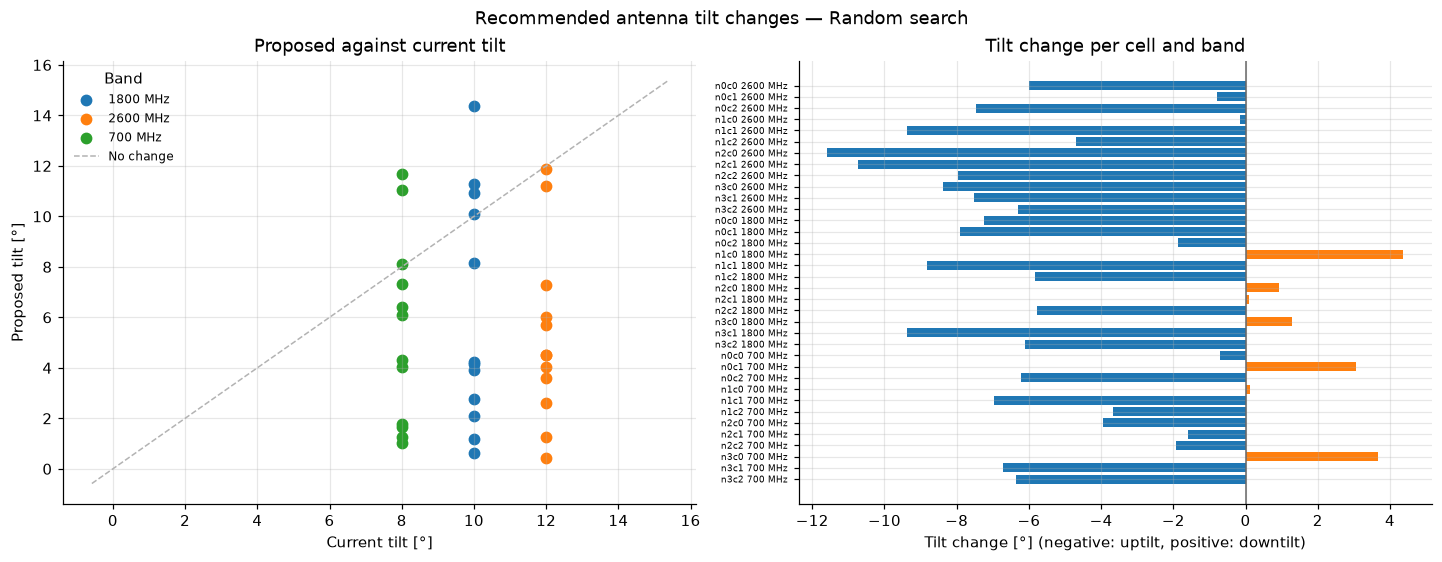

Rule-based sweep: run 2026-09-22_08-19-40, seed 42, best evaluation 21


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,8.3333,8.3333,-8.3333
1,2600 MHz,12,12,10.3333,10.3333,-10.3333
2,700 MHz,12,12,6.3333,6.3333,-6.3333


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,1.6667,-10.3333,0.0,15.0
1,n0c0,1800 MHz,10.0,1.6667,-8.3333,0.0,15.0
2,n0c0,700 MHz,8.0,1.6667,-6.3333,0.0,15.0
3,n0c1,2600 MHz,12.0,1.6667,-10.3333,0.0,15.0
4,n0c1,1800 MHz,10.0,1.6667,-8.3333,0.0,15.0
5,n0c1,700 MHz,8.0,1.6667,-6.3333,0.0,15.0
6,n0c2,2600 MHz,12.0,1.6667,-10.3333,0.0,15.0
7,n0c2,1800 MHz,10.0,1.6667,-8.3333,0.0,15.0
8,n0c2,700 MHz,8.0,1.6667,-6.3333,0.0,15.0
9,n1c0,2600 MHz,12.0,1.6667,-10.3333,0.0,15.0


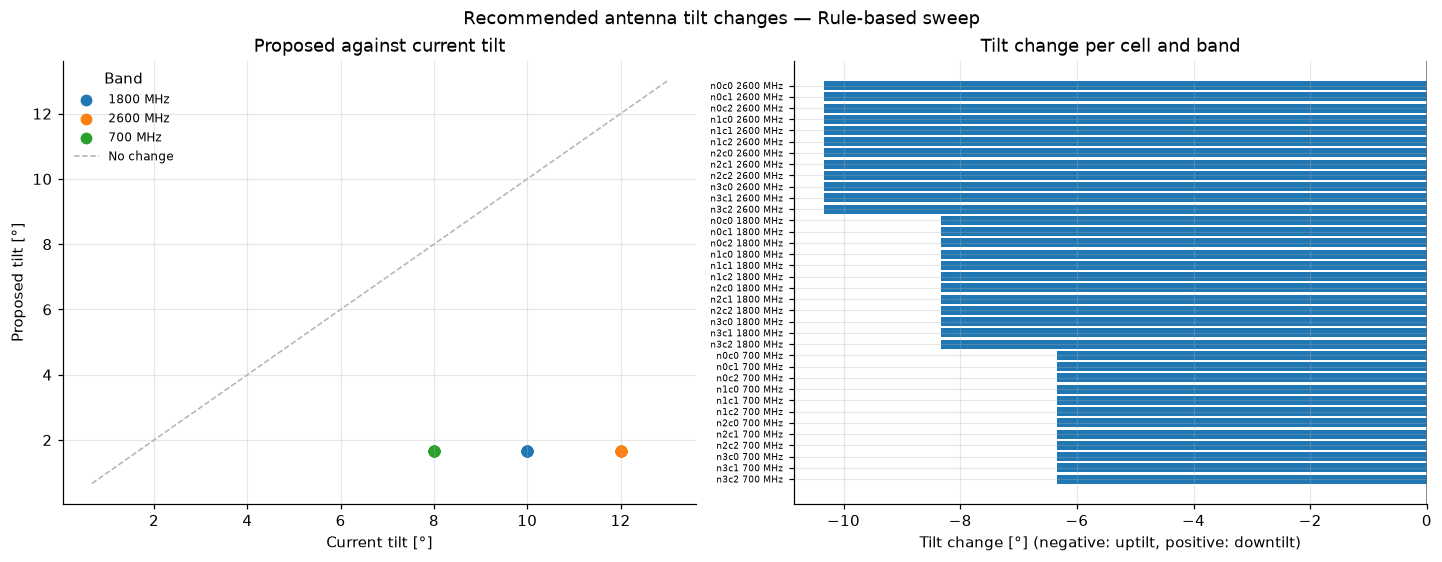

In [9]:
for method in METHODS:
    chosen = best[method]
    tilt = readable(chosen.best_tilt)
    save_table(tilt, f"best_tilt_{method}")
    summary = readable(compare.tilt_movement(chosen))
    save_table(summary, f"tilt_movement_{method}")
    print(f"{label(method)}: run {chosen.run_id}, seed {chosen.seed}, best evaluation {chosen.best_index}")
    display(summary)
    display(tilt)
    figure = plots.tilt_movement_plot(chosen.best_tilt, method)
    save_fig(figure, f"tilt_movement_{method}")
    plt.show()

**Observations.** The sweep sets every cell on every band to 1.67°. That is an uptilt of 10.33° on the high band,
8.33° on the mid and 6.33° on the low, applied identically to all twelve cells, since it can only move bands as a
whole. 1.67° is the second-lowest value on its grid, so the sweep stopped short of the 0° bound; the box is not what
limits it.

Random search's best point also uptilts every band on average, to 5.25° on 2600 MHz, 6.15° on 1800 MHz and 5.39° on
700 MHz. The amounts vary from 0.42° to 14.36°, and 7 of the 36 cell-bands are downtilted, with no visible pattern by
node. That spread is what one Sobol draw looks like, not evidence that those cells need different tilts.

## 10. Final Results

### KPI comparison

Each method's best configuration against the current one, on every UE. Relative improvement is signed so that
positive is better whichever direction the KPI runs:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

In [10]:
def kpi_comparison(chosen):
    table = compare.delta_table(chosen.incumbent_kpi, chosen.best_kpi)
    sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
    table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
    return table


for method in METHODS:
    table = readable(kpi_comparison(best[method])).rename(
        columns={
            "direction": "Direction",
            "before": "Initial",
            "after": label(method),
            "delta": "Change",
            "verdict": "Verdict",
            "improvement_pct": "Improvement [%]",
        }
    )
    save_table(table, f"kpi_comparison_{method}")
    print(label(method))
    display(table)

cost = readable(compare.method_table(runs).drop(columns=["run"]))
save_table(cost, "baseline_results")
cost

Random search


,KPI,Direction,Initial,Random search,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1083,-0.0042,better,3.7650
1,Co-band overlap rate,minimise,0.3164,0.3254,0.0090,worse,-2.8397
2,Overlap neighbours per covered tile,minimise,0.9625,1.0303,0.0678,worse,-7.0449
3,Weak coverage rate,minimise,0.3069,0.2864,-0.0206,better,6.6996
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-107.9820,0.5824,better,0.5365
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-82.7177,1.3892,better,1.6517
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-5.5418,0.3311,better,5.6372
7,"Median SINR, p50 [dB]",maximise,8.4932,9.2144,0.7211,better,8.4906
8,Served UE rate,maximise,0.5265,0.5882,0.0617,better,11.7115
9,Cell load imbalance (CoV),minimise,0.9098,1.0092,0.0994,worse,-10.9290


Rule-based sweep


,KPI,Direction,Initial,Rule-based sweep,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1044,-0.0081,better,7.1692
1,Co-band overlap rate,minimise,0.3164,0.3181,0.0017,worse,-0.5254
2,Overlap neighbours per covered tile,minimise,0.9625,1.1866,0.2240,worse,-23.2752
3,Weak coverage rate,minimise,0.3069,0.2535,-0.0534,better,17.3937
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-106.9675,1.5969,better,1.4709
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-80.7966,3.3102,better,3.9357
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-4.9663,0.9065,better,15.4362
7,"Median SINR, p50 [dB]",maximise,8.4932,9.9010,1.4078,better,16.5756
8,Served UE rate,maximise,0.5265,0.5988,0.0723,better,13.7262
9,Cell load imbalance (CoV),minimise,0.9098,0.9963,0.0865,worse,-9.5051


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,7,6.6332,10.3287,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,1.0092,0.6911,8,3
1,Rule-based sweep,42,111,21,4.5005,7.2360,0.1044,0.3181,1.1866,0.2535,-106.9675,-80.7966,-4.9663,9.9010,0.5988,0.9963,0.6963,8,3


**Observations.** Both baselines raise J: +4.68 % for the sweep and +3.90 % for random search. Counting the ten KPIs
and J, each improves 8 of the 11 measures. **The sweep is the stronger configuration on almost every view.** Against
random search, it:
- cuts the hole rate 7.2 % against 3.8 %, and weak coverage 17.4 % against 6.7 %;
- lifts median RSRP 3.3 dB against 1.4 dB, and median SINR 1.4 dB against 0.7 dB;
- serves more UEs (0.5988 against 0.5882).

**Neither baseline improves co-band overlap.** The sweep takes the overlap rate from 0.3164 to 0.3181, and random
search takes it to 0.3254. Both raise overlap neighbours per covered tile as well: the sweep by 23 % (0.963 to 1.187)
and random search by 7 % (to 1.030). Uptilting a whole band lifts every cell's footprint at once, so the footprints
meet in more places.

The objective does price that crowding, on every covered layer. For the sweep it is simply outweighed: its uniform
uptilts buy +0.046 of $J$ in signal strength and give back about 0.016 to contention (ADR 0003, Measured outcome).
Overlap-reducing candidates *existed*: the sweep evaluated one reaching an overlap rate of 0.3061, better than the
incumbent, and J did not select it.

Per band, 2600 MHz overlap **improves** under both methods (0.2010 to 0.1951 for the sweep and 0.1908 for random
search). 1800 MHz improves under random search only (0.1952). 700 MHz worsens under both (0.2441 and 0.2422).

**Cell load imbalance worsens under both**, by 9.5 % and 10.9 %, as traffic concentrates on the cells that serve it
best. Nothing in the objective asks for even load (ADR 0003).

**Every configuration runs at the 0.8 admission ceiling**, so the served-rate gains come from better SINR needing
fewer PRBs per UE, not from spare capacity. The median PRBs per served UE fall from 53.2 to 39.3 under the sweep and
39.8 under random search.

## 11. Coverage Map Comparison

Best-server RSRP before and after, and the tiles that crossed the coverage-hole threshold; then the RSRP change of
each method's best configuration. Crimson triangles are the masts.

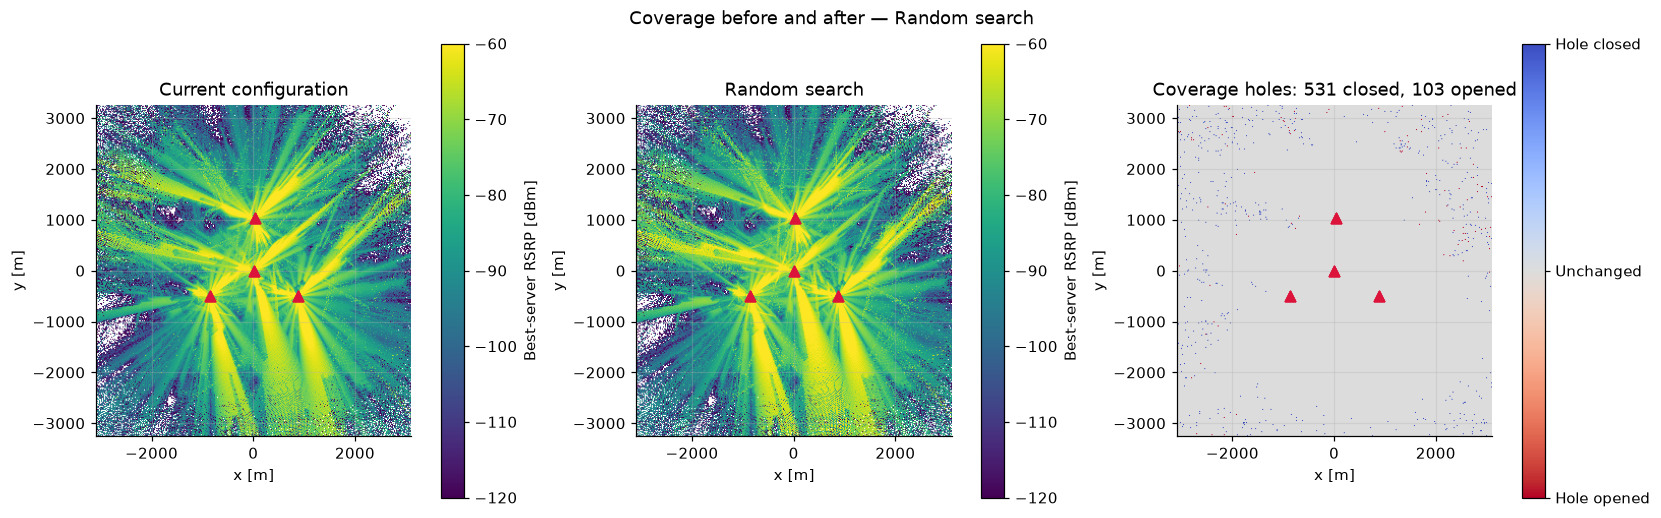

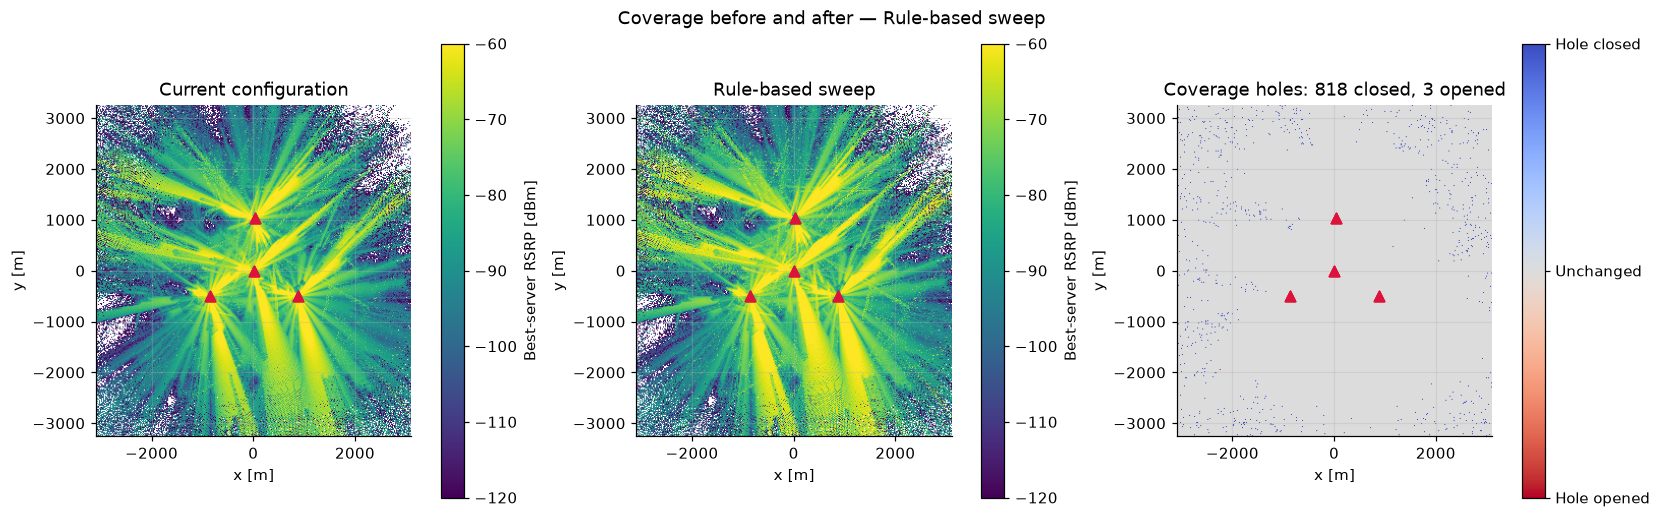

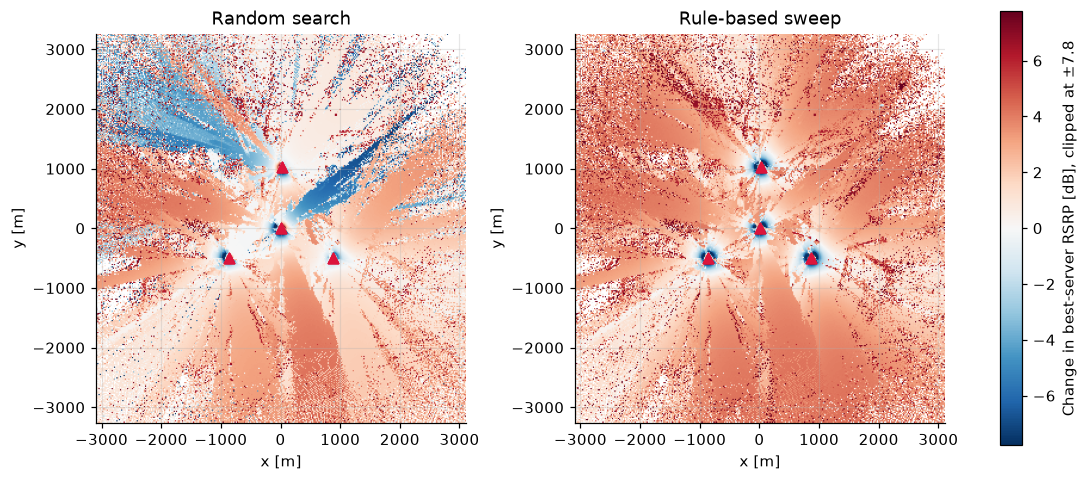

In [11]:
best_rsrp = {"incumbent": max_rsrp(baseline_rsrp)}
best_rsrp.update({method: max_rsrp(best[method].radio_map["rsrp_dbm"].astype(float)) for method in METHODS})

for method in METHODS:
    figure = plots.coverage_maps(
        best_rsrp["incumbent"], best_rsrp[method], baseline, cfg, cells=cells, name=method
    )
    save_fig(figure, f"coverage_before_after_{method}")
    plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

Regions worth inspecting: the cell edges between the three corner nodes and the centre node, the tiles that opened or
closed a hole, and heavily overlapped areas near the masts.

**Observations.** Both baselines raise best-server RSRP almost everywhere, and the sweep does it most evenly. It
improves 96.9 % of reached tiles by a median of 3.3 dB, closing 818 hole tiles while opening 3. Random search is the
weaker and noisier of the two: 80.6 % of tiles improve, by a median of 1.5 dB, with 531 holes closed and 103 opened.
A single Sobol draw uptilts some cells far more than their neighbours and trades one area against another.

This signal gain does score. The strength factor rewards every band's strongest cell for moving towards $-90$ dBm,
so the sweep's 3.3 dB shows in $J$ as well as in `rsrp_p50_dbm`.

## 12. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs. Demand is the incumbent's, for every
configuration, so the weights do not move. The project has no band-priority score; the serving-band mix is read
against the preference order `kpi.capacity.band_preference` instead.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.1125,0.000,0.1083,0.0027,0.1044,0.0000
1,weak,0.3069,0.836,0.2864,0.7967,0.2535,0.7673
2,good,0.5806,0.164,0.6054,0.2006,0.6420,0.2327


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.3164,0.9625
1,Random search,0.3254,1.0303
2,Rule-based sweep,0.3181,1.1866


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,Random search,10087.0,0.4118,0.2418,7.7253,39.8052,0.4506,0.0715,0.0661
2,Rule-based sweep,10087.0,0.4012,0.3564,7.8600,39.2656,0.4629,0.0638,0.0721


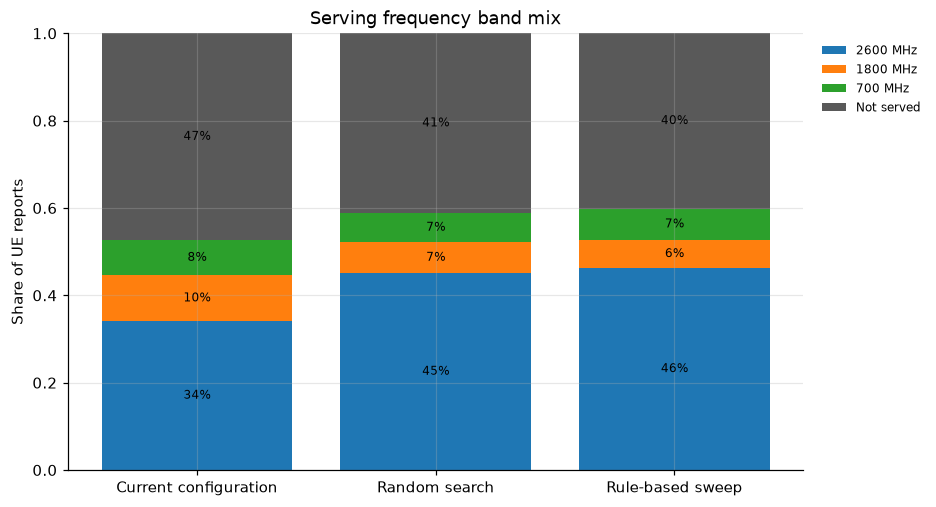

,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,prb_utilisation_max,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,Random search,All bands,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092
5,Random search,2600 MHz,0.2587,0.1908,0.3972,0.4077,-113.9217,-91.9628,-16.1259,2.5799,0.4506,0.7998,0.5835
6,Random search,1800 MHz,0.2260,0.1952,0.3442,0.3546,-111.7681,-88.4004,-11.0177,6.1660,0.0715,0.7997,0.9939
7,Random search,700 MHz,0.1359,0.2422,0.4142,0.2831,-108.2549,-82.9697,-5.1376,8.6310,0.0661,0.7988,1.1114
8,Rule-based sweep,All bands,0.1044,0.3181,1.1866,0.2535,-106.9675,-80.7966,-4.9663,9.9010,0.5988,0.7999,0.9963
9,Rule-based sweep,2600 MHz,0.2514,0.1951,0.4288,0.3821,-113.3120,-90.4014,-15.5123,3.5452,0.4629,0.7999,0.5643


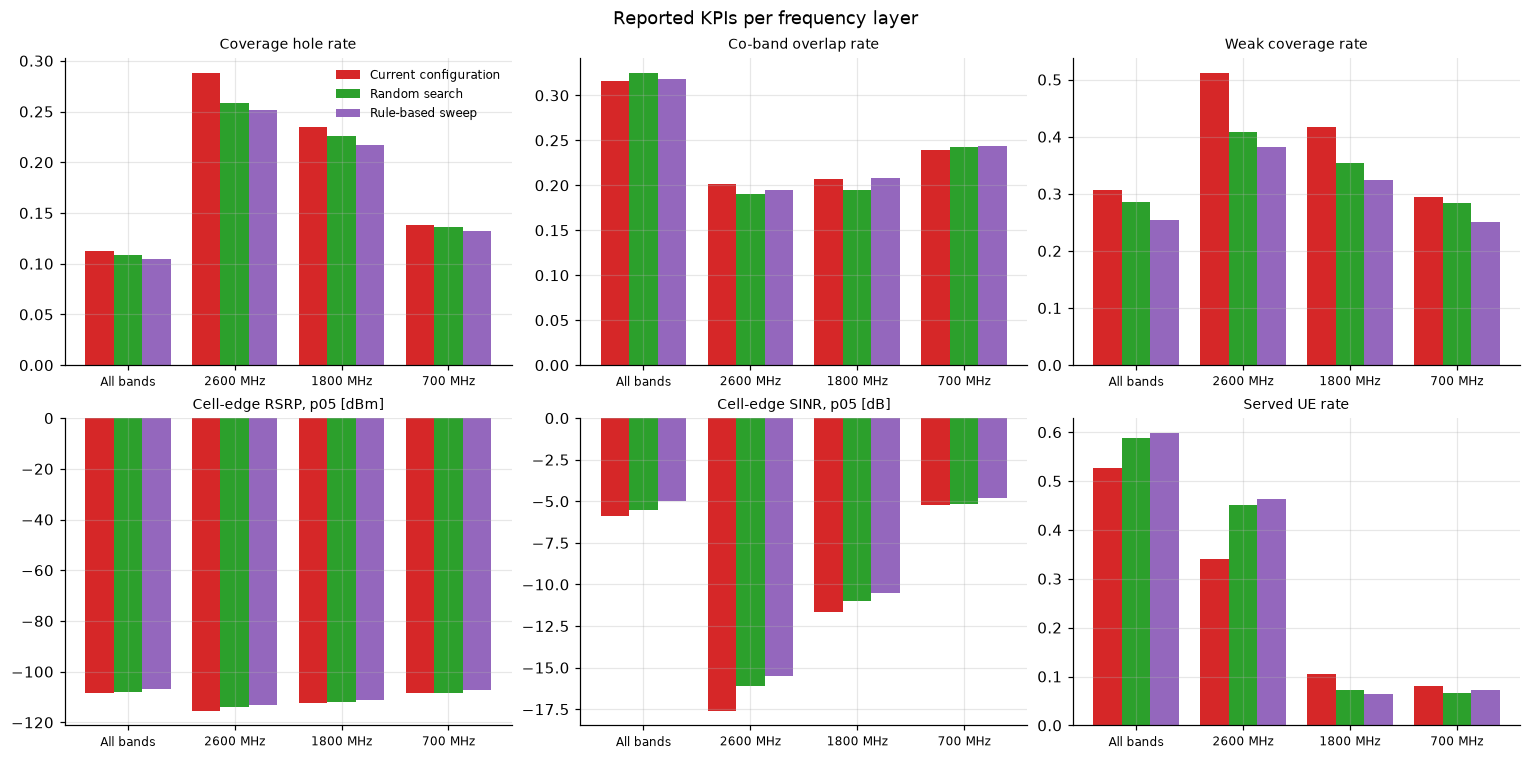

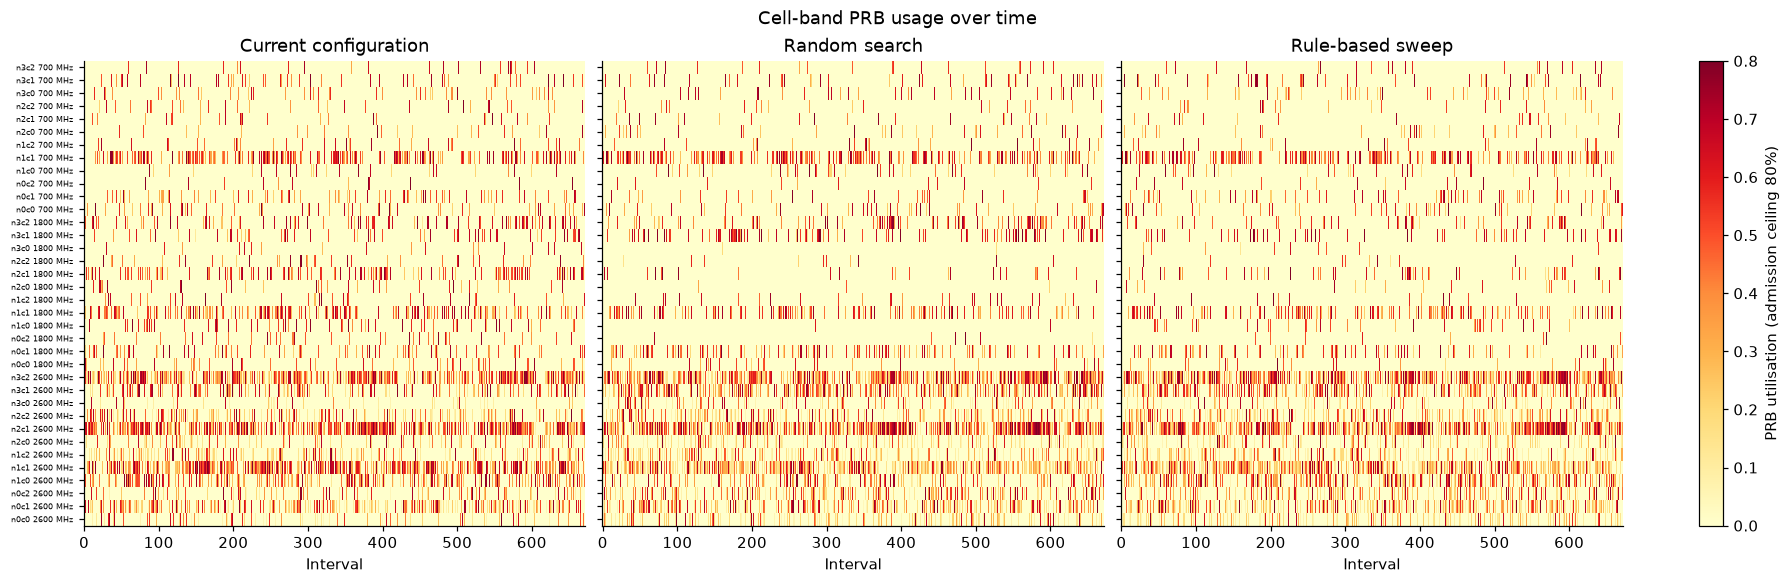

peak utilisation over every cell-band and interval: 80.0% (admission ceiling 80%)


In [12]:
configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [runs[0].incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [mean_overlap_neighbors(c.rsrp) for c in configurations.values()],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print("Band preference, most preferred first:", ", ".join(label(b) for b in cfg.kpi.capacity.band_preference))
service = {name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

tx_names = [str(name) for name in baseline["tx_name"]]
max_prb = CapacitySpec.from_config(cfg, band_labels, len(tx_names)).max_prb

# Every reported KPI, over all bands and per band, through the same functions:
# a band row is the definition given one band's layers, nothing new.
per_band = compare.band_kpis(configurations, band_labels, cfg)
save_table(readable(per_band), "band_kpis")
display(readable(per_band))
figure = plots.band_kpi_panels(
    per_band,
    ("hole_rate", "overlap_rate", "weak_rate", "rsrp_p05_dbm", "sinr_p05_db", "served_rate"),
)
save_fig(figure, "band_kpis")
plt.show()

# The series prb_utilisation_max and load_imbalance reduce. The admission
# ceiling bounds every cell in it, so a band running at the ceiling is a cell
# that refused traffic, not one that overloaded.
ceiling = float(cfg.kpi.capacity.max_admission_utilisation)
usage = compare.prb_usage_by_time(configurations, band_labels, tx_names, max_prb)
save_table(readable(usage), "prb_usage_by_time")
figure = plots.prb_usage_heatmaps(usage, ceiling)
save_fig(figure, "prb_usage")
plt.show()
print(f"peak utilisation over every cell-band and interval: {usage['utilisation'].max():.1%} "
      f"(admission ceiling {ceiling:.0%})")


### Coverage holes

Both baselines cut the hole rate by area: 0.1125 falls to 0.1044 for the sweep and 0.1083 for random search. The
current configuration has no demand on hole tiles. The sweep still moves none onto them, and random search moves
0.27 %.

### Coverage overlap

Neither baseline improves overlap on the reported, band-collapsed measure.
- **The sweep** raises the overlap rate from 0.3164 to 0.3181 and the mean number of overlapping neighbours over
  covered tiles from 0.963 to 1.187. It also thickens the pile-ups: 18.1 % of covered tiles have three or more
  neighbours, against the incumbent's 17.6 %.
- **Random search** raises the rate to 0.3254 and the mean to 1.030, but leaves fewer tiles with three or more
  neighbours (16.8 %).

Split by band, 2600 MHz improves under both: 0.2010 falls to 0.1951 under the sweep and 0.1908 under random search.
1800 MHz improves under random search only, and 700 MHz worsens under both. The newly covered ground also arrives
with neighbours of its own. Together, that is what lifts the collapsed rate.

### Multi-band coordination

The share of UE reports served on 2600 MHz, the preferred band, grows from 34.1 % to 46.3 % for the sweep and 45.1 %
for random search. Meanwhile 1800 MHz falls from 10.5 % to 6.4 % and 7.1 %, and 700 MHz from 8.1 % to 7.2 % and
6.6 %. The served ratio rises with it. Served SINR improves at the median (5.1 to 7.9 dB for the sweep, 7.7 dB for
random search) and at the 10th percentile (-0.38 to +0.36 and +0.24 dB). TuRBO also pushes traffic onto 2600 MHz;
see notebook 03b.

### Weak coverage

Weak coverage falls by area for the sweep (30.7 % to 25.4 %) and for random search (to 28.6 %). The share of demand on
weak tiles falls with it, from 83.6 % to 76.7 % and 79.7 %. It is still where most of the demand sits.

## 13. Key Observations

- **The current tilts are downtilted relative to what either baseline prefers.** The current per-band tilts are 12°,
  10° and 8°. Both baselines uptilt every band on average, and both gain: +4.68 % on J for the sweep and +3.90 % for
  random search.
- **Structure beats sampling.** A three-variable sweep beat 36-variable random search on J at about two-thirds of the
  ray-tracing cost (4.5 against 6.6 minutes). Random search found its best at evaluation 7 of 145 and never improved
  after that: its budget is spread too thinly over a 36-dimensional box to add anything beyond the initial design.
- **The gains are broad rather than narrow.** The sweep improves the hole rate, weak coverage, both RSRP percentiles,
  both SINR percentiles and the served rate at once, and closes 818 hole tiles while opening 3.
- **Neither baseline fixes overlap or load.** Both raise the overlap rate and the neighbour count, both leave peak
  utilisation at the admission ceiling, and both make the load less even. Overlap is the gap a per-cell-band search
  can close and a per-band sweep structurally cannot; TuRBO closes it (notebook 03b).
- **The sweep is not limited by the bounds.** It sets every band to 1.67°, not the 0° bound.
- **These are one seed on one scenario;** notebook 04 reports intervals over seeds.

## 14. Baseline Limitations

- **Random search** does not model the objective landscape or reuse what earlier evaluations revealed; with 36
  variables, a fixed budget covers the box only sparsely. Its best point here is evaluation 7 of 145.
- **The rule-based sweep** cannot give cells on one band different tilts, so it cannot fix a local problem without
  moving every cell on that band, and coordinate descent stops at the first configuration no single band can improve.
  It is also the method that raises the overlap neighbour count most, for the same reason.
- Every candidate costs a full ray trace, so either method's result depends on the budget it was given.
- The winner is the best of many evaluations under one solver seed, so its score is biased upward (notebook 04,
  threats to validity).
- Neither method constrains how far an antenna moves; tilt change is reported, not penalised, and both move all 36
  cell-bands.

## 15. Baselines vs. the Proposed Method

| Property | Random search | Rule-based sweep | TuRBO (notebook 03b) |
| --- | --- | --- | --- |
| Search strategy | Sobol sampling over the box | Shared tilt per band, coordinate descent | Trust-region Bayesian optimization |
| Surrogate model | No | No | Gaussian process |
| Uses previous evaluations | No | Only the current best | Yes, to fit the model and move the trust region |
| High-dimensional search | Uniform coverage, thins with dimension | Collapses 36 variables to 3 | Local trust region around the best point |
| Simulations | `n_init + n_iter` | `n_band · n_steps · n_rounds` at most | `n_init + n_iter`, as random search |
| Best objective | Section 10 | Section 10 | Notebook 04 |

All three share the initial network state, simulator, scenario, constraints and objective; random search and TuRBO
also share the evaluation budget and the initial Sobol design. The comparison with confidence intervals over seeds is
in notebook 04.

## 16. Conclusion

The baselines set a reproducible reference for multi-band tilt optimization on this scenario. They show:

- the improvement a simple strategy reaches, led by the rule-based sweep (+4.68 % on J in 111 evaluations);
- how tilt drives the objective here: the current configuration is over-downtilted, and uptilting every band buys
  coverage, signal quality and served traffic together;
- the measures that resist both baselines: the co-band overlap rate, overlap neighbours per covered tile and cell load
  imbalance;
- that unstructured search over the 36-dimensional tilt space is inefficient at this budget.

TuRBO (notebook 03b) has to beat the rule-based sweep, not just random search, to justify its cost; notebook 04
makes that comparison.